# Step 5: Model Evaluation & Performance Analysis

In this notebook, we perform a deep-dive evaluation of our three trained machine learning models:
- Logistic Regression
- Random Forest
- Gradient Boosting

We will compute classification reports, plot confusion matrices, plot comparative ROC curves, extract feature importance rankings, and choose our best-performing model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
df = pd.read_csv("../data/processed/feature_engineered_data.csv")
print(f"Loaded feature-engineered dataset shape: {df.shape}")

Loaded feature-engineered dataset shape: (3878, 31)


In [3]:
# Prepare data
X = df.drop(columns=["Date", "Target", "Future_Close"])
y = df["Target"]

In [4]:
# Train-Test Split (consistent with model training)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print(f"Test set size: {X_test.shape[0]} rows")

Test set size: 776 rows


In [5]:
# Load Models
lr = joblib.load("../models/logistic_regression.pkl")
rf = joblib.load("../models/random_forest.pkl")
gb = joblib.load("../models/gradient_boosting.pkl")
scaler = joblib.load("../models/scaler.pkl")
print("Models and Scaler loaded successfully.")

Models and Scaler loaded successfully.


In [6]:
# Scale Test Data
X_test_scaled = scaler.transform(X_test)

In [7]:
# Make Predictions and Probabilities
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

gb_pred = gb.predict(X_test_scaled)
gb_prob = gb.predict_proba(X_test_scaled)[:, 1]

In [8]:
def evaluate_model(name, y_true, y_pred):
    print("="*40)
    print(name)
    print("="*40)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print()
    print(classification_report(y_true, y_pred))

evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("Gradient Boosting", y_test, gb_pred)

Logistic Regression
Accuracy : 0.5412371134020618
Precision: 0.5492307692307692
Recall   : 0.85
F1 Score : 0.6672897196261682

              precision    recall  f1-score   support

           0       0.50      0.18      0.26       356
           1       0.55      0.85      0.67       420

    accuracy                           0.54       776
   macro avg       0.52      0.51      0.46       776
weighted avg       0.53      0.54      0.48       776

Random Forest
Accuracy : 0.4845360824742268
Precision: 0.5980392156862745
Recall   : 0.14523809523809525
F1 Score : 0.23371647509578544

              precision    recall  f1-score   support

           0       0.47      0.88      0.61       356
           1       0.60      0.15      0.23       420

    accuracy                           0.48       776
   macro avg       0.53      0.52      0.42       776
weighted avg       0.54      0.48      0.41       776

Gradient Boosting
Accuracy : 0.5425257731958762
Precision: 0.5831202046035806
Reca

In [9]:
# Accuracy Comparison Table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1_Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})
results

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.541237,0.549231,0.850000,0.667290
1,Random Forest,0.484536,0.598039,0.145238,0.233716
2,Gradient Boosting,0.542526,0.583120,0.542857,0.562269


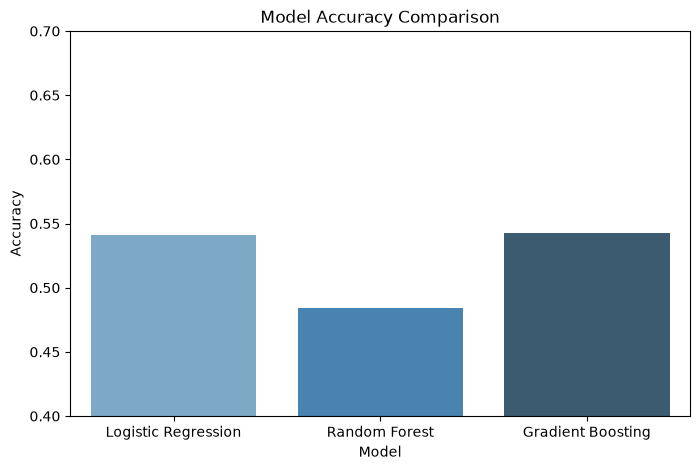

In [10]:
# Plot Accuracy comparison
plt.figure(figsize=(8,5))
sns.barplot(data=results, x="Model", y="Accuracy", hue="Model", legend=False, palette="Blues_d")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.4, 0.7)
plt.show()

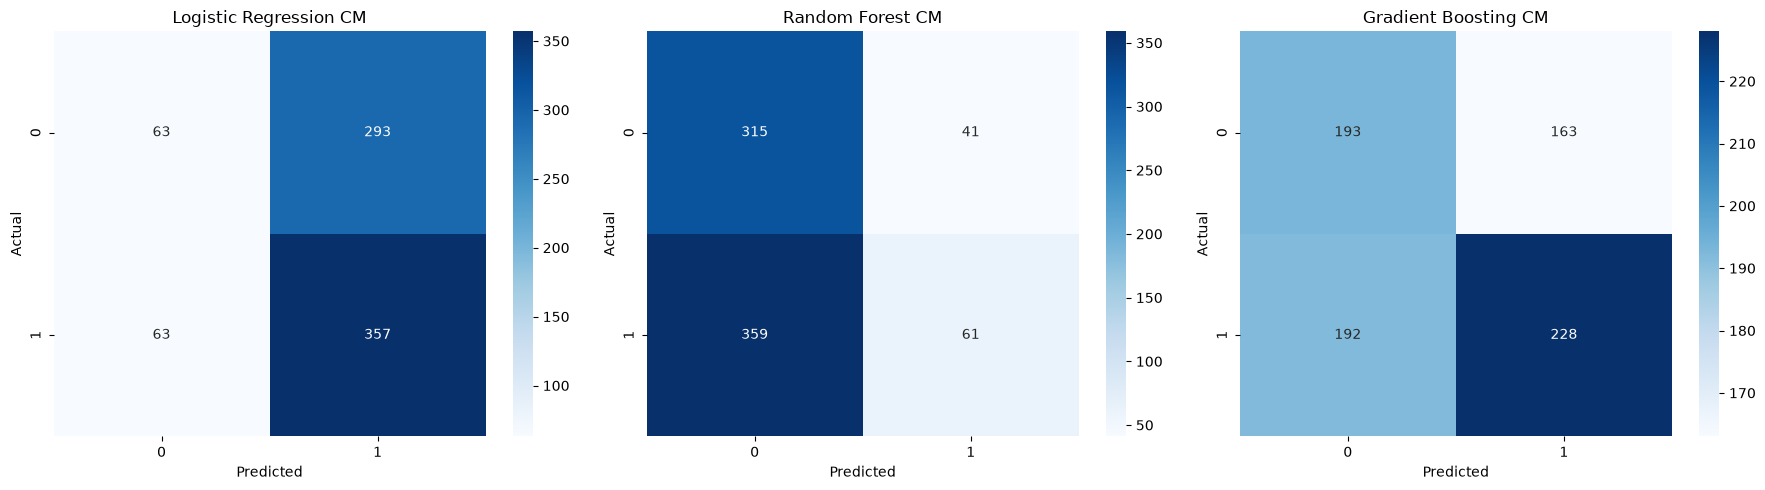

In [11]:
# Confusion Matrices plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_preds = [
    ("Logistic Regression", lr_pred),
    ("Random Forest", rf_pred),
    ("Gradient Boosting", gb_pred)
]

for i, (name, pred) in enumerate(models_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=axes[i])
    axes[i].set_title(f"{name} CM")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

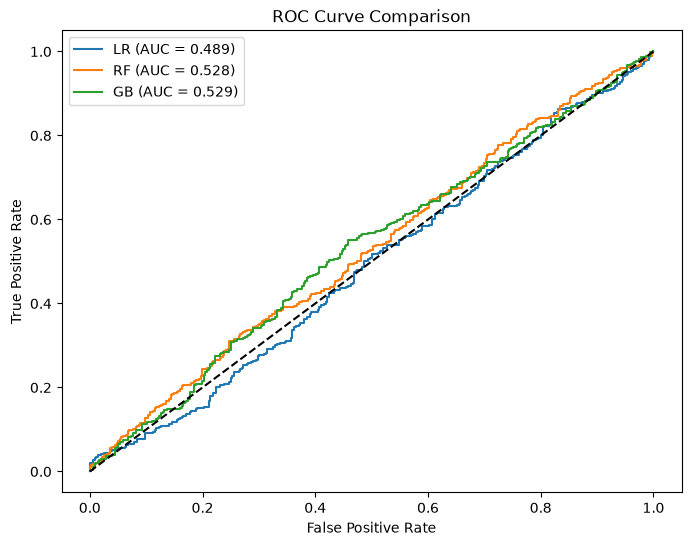

In [12]:
# ROC Curve plotting
plt.figure(figsize=(8,6))

for name, prob in [("LR", lr_prob), ("RF", rf_prob), ("GB", gb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

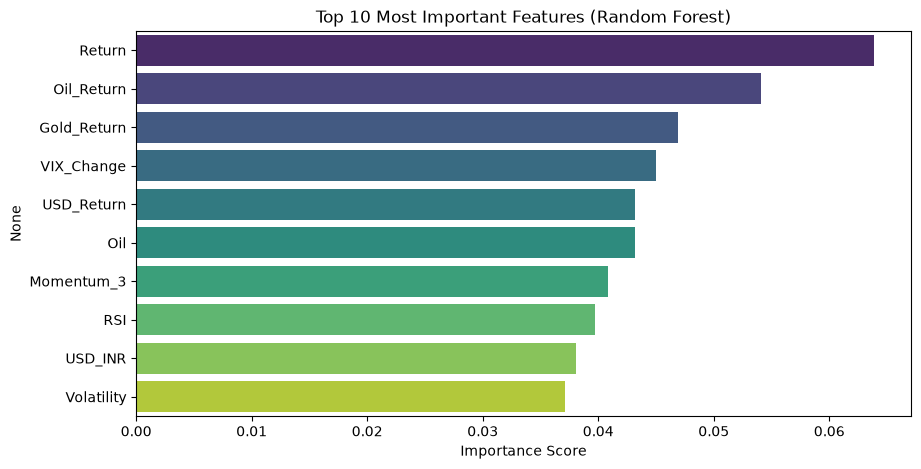

In [13]:
# Feature Importance (Random Forest)
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=importance.head(10).values, y=importance.head(10).index, hue=importance.head(10).index, legend=False, palette="viridis")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

In [14]:
# Best Model Selection
best_model_info = results.sort_values(by="Accuracy", ascending=False).iloc[0]
print(f"Best Model: {best_model_info['Model']} with Accuracy of {best_model_info['Accuracy']:.4f}")

Best Model: Gradient Boosting with Accuracy of 0.5425


In [15]:
# Save Results Comparison Table
results.to_csv("../data/processed/model_results.csv", index=False)
print("Saved comparison metrics to data/processed/model_results.csv")

Saved comparison metrics to data/processed/model_results.csv
